# **Clase 20 - Large Language Models**

MDS7202: Laboratorio de Programación Científica para Ciencia de Datos

## **Objetivos**

- Conocer qué son los LLM y cómo trabajarlos
- Framework LangChain para uso de LLM
- Aprender a generar chains de prompts
- Output parsers como solución a la interacción código-LLM
- Usar modelos con output estructurado y entender su relevancia en programación con LLM
- Comprender la importancia del contexto e historial para la construcción de chatbots

## **Configuración Inicial 🧐**

Para esta clase necesitaremos configurar las credenciales de algunos servicios a utilizar, en específico:

### **Google AI Studio**

Usaremos `Google AI Studio` para habilitar el uso de LLMs y Embeddings de Google. Simplemente deben registrarse con su cuenta google y obtener su API KEY desde el siguiente enlace: [Google AI Studio](https://aistudio.google.com/app/u/1/apikey).

### **Tavily**

En paralelo, utilizaremos `Tavily` como motor de búsqueda para potenciar las respuestas de nuestros agentes. Tal como en el paso anterior, solo deben registrarse y obtener su API KEY desde el siguiente enlace: [Tavily](https://tavily.com/).

### **Configurar credenciales en ambiente**

Una vez se tienen todas las credenciales, pasamos a activarlas en nuestro ambiente local por medio del siguiente código:

In [1]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

O si les sale más fácil, también pueden hacerlo a través de un archivo **.env** (esto funciona mejor cuando trabajan desde sus máquinas locales).

Sólo debemos crearlo y escribir en él todas las credenciales:

```python
GOOGLE_API_KEY="<YOUR_GOOGLE_API_KEY>"
TAVILY_API_KEY="<YOUR_TAVILY_API_KEY>”
```

Luego, cargamos las credenciales al ambiente:

## **Agentes 🕵️‍♂️**

Ahora que ya conocemos cómo utilizar LLMs, parsear prompts, construir y llamar chains, utilizar embeddings y construir sistemas de RAG estamos listos para aprender sobre cómo implementar **Agentes**.

Todo genial, pero...

### **¿Qué son los Agentes?**

Un agente se define como un modelo que utiliza chains para tomar **decisiones** y ejecutar **acciones**. De esta manera, el objetivo del agente es **elegir una <u>secuencia</u> de acciones** a realizar para cumplir con un objetivo específico.

> **Pregunta**: Ok, pero entonces cual es la diferencia con las chains?

Si bien las **chains** tienen la capacidad de implementar una secuencia de acciones o pasos, estas acciones estan **programadas de manera fija** en el código. En contraste, los **agentes** utilizan el **LLM como <u>motor de razonamiento</u>** para determinar **qué acciones tomar y en qué orden**.

Un poco más concretamente, los agentes son capaces de **orquestar** múltiples chains en un **grafo de decisión**. En este proceso, las chains se ejecutan en **nodos** donde extraen y almacenan información proveniente del razonamiento del LLM y que permiten decidir el próximo nodo, tomar acciones, y compartir información entre ellas.

Antes de adentrarnos a la profundidad del estado del arte de los agentes, aprendamos a utilizar una de las librerías más conocidas para orquestar agentes

<center>
<img src='https://media4.giphy.com/media/dBZsIa2eWkVBaU6lWY/giphy.gif' width=450/>
</center>

### **Langgraph**

Las cadenas tradicionales de LLM  siguen una estructura lineal y secuencial: el paso A va al paso B, y el paso B al paso C. Sin embargo, las aplicaciones de IA más avanzadas—los Agentes—requieren un comportamiento humano: la capacidad de razonar, cometer errores, retroceder y repetir un proceso hasta encontrar la respuesta correcta.

Ahí es donde entra LangGraph. Es una librería diseñada para crear flujos de trabajo con LLMs que permiten ciclos y bucles, orquestando la lógica mediante una arquitectura basada en **Grafos de Estado**.

#### **Elementos de Langgraph**

Para entender y construir cualquier flujo en LangGraph, tus alumnos deben dominar cuatro conceptos clave:

1. El Estado (State)
Es la única fuente de verdad y la memoria centralizada del grafo. Es una estructura de datos (normalmente un TypedDict) que se pasa de nodo en nodo. Cada componente del grafo puede leer datos del estado o escribir actualizaciones en él.

2. Los Nodos (Nodes)
Son funciones de Python puras que ejecutan la acción. Toman el State actual como entrada, realizan una tarea (como llamar a un LLM, consultar una base de datos o transformar un texto) y luego pueden **modificar el estado** al retornar una modificación y/o indicar el **siguiente nodo** mediante un `Command`

3. Los Bordes o Aristas (Edges)
Definen las conexiones del ciclo de vida y la dirección del flujo. Unen un nodo con el siguiente de forma estática (por ejemplo, el inicio del grafo START hacia nuestro primer nodo, o el final de un nodo hacia END). Pueden ser definidos en el momento de creación del grafo o en las salidas de los nodos.

4. El Comando de Control (Command)
Es la herramienta moderna de LangGraph para el enrutamiento dinámico. Es un objeto que un nodo retorna cuando necesita tomar una decisión sobre la marcha. Desde el interior del nodo, Command permite aplicar cambios al estado y, al mismo tiempo, indicarle explícitamente al grafo cuál es el siguiente nodo al que debe dirigirse (goto).


***¡Manos a la Obra!***

In [1]:
!uv add langgraph

Resolved 225 packages in 5.32s
Prepared 4 packages in 781ms
Uninstalled 1 package in 128ms
Installed 6 packages in 605ms
 + langgraph==1.2.4
 + langgraph-checkpoint==4.1.1
 + langgraph-prebuilt==1.1.0
 + langgraph-sdk==0.4.2
 + ormsgpack==1.12.2
 - websockets==16.0
 + websockets==15.0.1


### **Grafo simple generador/revisor**

A modo didáctico, construiremos un grafo muy simple con 2 nodos: uno **generador** y otro **revisor**. El nodo generador recibe la pregunta del usuario y genera la respuesta, y luego el nodo revisor evalúa si la respuesta está realmente basada en el contexto.

<center>
<img src='./generador_revisor.png' width=600/>
</center>

Comenzamos definiendo un estado

In [4]:
from typing import TypedDict

# 1. Definir el Estado
class State(TypedDict):
    question: str="" # La pregunta del usuario
    generation: str="" # La respuesta generada por el nodo generador
    context: str="" # La información en base a la que responderá
    correction: str="" # En caso que el revisor no acepte la generación
    n_iter: int=0 # Necesario para evitar loops infinitos

> 👁️ **Ojo**: El estado no es una memoria persistente. Sólo existe dentro de **una sola llamada** al modelo. Es válida dentro del ciclo de orquestación que eventualmente termina, momento en el cual se responde al usuario y se reinicia la memoria. En la siguiente llamada al grafo la memoria ya no existirá.

Luego empezamos a generar los nodos. Comenzamos con el generador. Los nodos, en su mayoría, utilizan chains. Esto no es obligatorio, pero ya que el objetivo es utilizar LLMs para tomar decisiones, es el caso general. Por esto, cada nodo en general tiene un prompt, un llm y, de ser necesario, un output parser.

In [24]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langgraph.types import Command

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", 
    temperature=2.0, # Le damos creatividad para que tenga sentido el corrector
)

# Le damos aun más creatividad en el prompt.
prompt_generador = """
Eres un asistente al usuario y tu rol es responder sus preguntas dado un contexto. 
Sé creativo en tus respuestas. Una respuesta entretenida es más importante que una respuesta
correcta. Si recibes una corrección, dale prioridad a esa instrucción por sobre todo.
Sé BREVE, no más de 2 líneas. Y que tus respuestas estén al límite de la veracidad.

Contexto: {context}

Generacion anterior: {previous_generation}

Corrección: {correction}

Pregunta usuario: {question}
"""

def nodo_generador(state: State): # Todos los nodos toman el estado como
    print("--- NODO GENERADOR: Creando respuesta ---")
    feedback_revisor = state.get("correction", "")
    contexto = state.get("context", "")
    pregunta = state.get("question", "")
    generacion_anterior = state.get("generation", "")
    
    prompt_template = PromptTemplate.from_template(prompt_generador)
    chain = prompt_template | llm | StrOutputParser()

    input_chain = {
        "context": contexto,
        "correction": feedback_revisor,
        "question": pregunta,
        "previous_generation": generacion_anterior
    }

    generacion = chain.invoke(input_chain) # Llamada de chain en base a campos del estado
    
    return Command(
        update={"generation": generacion}, # Actualizar estos campos
        goto="nodo_revisor" # Luego de generar, vamos al nodo revisor
    )

El nodo generado generará la respuesta a la pregunta en base al contexto, actualiza el campo `generation` con su respuesta, y luego pasamos al nodo revisor.

El nodo revisor va a tomar la respuesta generada por el agente anterior, el contexto y la pregunta y evaluará si realmente respondió la pregunta. En base a esto tomará una **decisión**: si alucinó entonces volverá al nodo generador con una correción, y si no entonces seguirá adelante. Por esto, necesitaremos de un **modelo con output estructurado**, que vimos en las clases anteriores que sirve para transformar análisis semántico en decisiones _duras_ de código.

Si el revisor rechaza la generacion demasiadas veces, simplemente se cortará el flujo y se responderá un mensaje genérico de "No se puede generar la respuesta"

In [25]:
from langgraph.graph import END

from pydantic import BaseModel, Field
from typing import Literal

# Mucho más riguroso, pero ojo que también usa un llm con creatividad = 2.0
prompt_revisor = """
Eres un riguroso revisor de hechos. Tu rol es evaluar factualmente si una respuesta generada por
un LLM no confiable está realmente basada en el contexto dado y responde una pregunta realizada
por un usuario.

De ser el caso que no esté basada en el contexto, genera una corrección detallada pero de no más
de 3 lineas

Contexto: {context}

Pregunta usuario: {question}

Respuesta generada: {generation}
"""

# Modelo de output estructurado
class EvaluarAlucinacion(BaseModel):
    evaluacion: Literal["alucinacion", "correcto"] = Field(
        description="Alucinacion: La generacion no responde a la pregunta o no esta basada en el " \
        "contexto. Correcto: La generacion responde a la pregunta en base al contexto"
    )
    correccion: str = Field(
        description="Detalle de las consideraciones y cambios a realizarle a la generacion anterior"
    )

def nodo_revisor(state: State):
    print("--- NODO REVISOR: Revisando respuesta ---")
    generacion_anterior = state.get("generation", "")
    contexto = state.get("context", "")
    pregunta = state.get("question", "")
    
    prompt_template = PromptTemplate.from_template(prompt_revisor)
    structured_model = llm.with_structured_output(EvaluarAlucinacion)
    chain = prompt_template | structured_model

    input_chain = {
        "context": contexto,
        "question": pregunta,
        "generation": generacion_anterior,
    }

    revision: EvaluarAlucinacion = chain.invoke(input_chain)

    n_iter = state.get("n_iter", 0)
    if revision.evaluacion == "alucinacion":
        if n_iter < 3:
            return Command(
                update= {
                    "generation": revision.correccion, # Agregar una correccion al generador
                    "n_iter": n_iter + 1 # Como damos una vuelta más agregamos una iteracion
                }, 
                goto="nodo_generador" # Vamos al revisor
            )
        else:
            return Command(
                update= {"generation": "Lo siento, no logré generar una respuesta"}, 
                goto=END # Terminamos el ciclo con un mensaje genérico (rechazo)
            )
    elif revision.evaluacion == "correcto": # Terminamos el ciclo con la generación ya dada
        return Command(goto=END)

> 🤔 Puede ser un poco redundante hacer 2 llamadas a un LLM para evitar aluciones: Cómo sabemos que el segundo LLM no alucinó? Si bien usar el mismo modelo para el nodo revisor puede ser contraintuitivo, es más probable que un modelo de lenguaje alucine al pedirle _"Genera una respuesta correcta a esta pregunta según este contexto"_ que al pedirle _"verifica si esta respuesta responde a la pregunta en base a este contexto"_. La segunda petición es directa, es una pregunta de _si o no_, y tiene menor carga cognitiva ya que basta con buscar la respuesta en el contexto.

Ya teniendo ambos nodos, podemos generar el grafo completo. Para esto, debemos definir un StateGraph (un grafo que tiene estado, básicamente) y registrar los nodos en él con sus nombres. Si los nodos utilizan la función `Command` para indicar el siguiente nodo, entonces solo quedaría definir el nodo de inicio o **entrypoint**. Si no, entonces sería necesario definir también las aristas o _edges_.

In [26]:
from langgraph.graph import StateGraph

workflow = StateGraph(State)

# Registramos nodos con sus nombres
workflow.add_node("nodo_generador", nodo_generador)
workflow.add_node("nodo_revisor", nodo_revisor)

# Definimos punto de entrada
workflow.set_entry_point("nodo_generador")

# Compilar
langraph_app = workflow.compile()



> 🔂Hasta hace no mucho tiempo, el estándar para la definición del grafo (de qué nodo se pasa a qué nodo y en qué condiciones) era definir el grafo con `graph.add_edge("nodo_1", "nodo_2")` para una conexión simple entre 2 nodos o `graph.add_conditional_edges("nodo_origen", funcion_decision, {"salida", "nodo_destino_1", ...})` para una conexión condicional. Hoy el estándar es usar `Command`, lo cual hace que el código sea mucho más sencillo, con la única desventaja significativa de que cada nodo queda amarrado a una decisión y a un nombre de nodo, que en la práctica casi nunca afecta.

***¿Y la pregunta? ¿Y el contexto?***

En efecto, estos 2 campos son los únicos que no se definen ni son modificados a través de los nodos. Entonces, ¿De donde vienen?

La respuesta es simple, si hay campos que no son tocados por los nodos entonces deben ser dados como inputs al llamar al grafo. En realidad, esto aplica para todos los campos del estado: Incluso si son modificados internamente en el grafo pueden ser seteados al momento de llamar el grafo.

Entonces, invocar el grafo implica iniciar el ciclo de decisión dándole ciertos parámetros del estado, de esta forma:

In [29]:
context = """
En el diseño de sistemas con LLMs, LangGraph se posiciona como la librería estándar para construir 
flujos de trabajo cíclicos basados en grafos de estado. A diferencia de las cadenas lineales 
tradicionales (LCEL), un desarrollo en LangGraph permite que el estado del sistema (State) mute y 
regrese a nodos anteriores para corregir errores, simulando un proceso de autorreflexión. El control
de este flujo dinámico se gestiona modernamente mediante el objeto Command, el cual permite que un
nodo actualice el estado y decida de forma autónoma su próximo destino en tiempo de ejecución
(utilizando el argumento goto), eliminando la necesidad de configurar enrutadores externos rígidos.

Sin embargo, para que este flujo deje de ser un script predecible y se transforme en un Agente 
Inteligente Autónomo (ReAct), el LLM necesita interactuar con el mundo exterior. Esto se logra
mediante el ecosistema de Herramientas (Tools) y abstracciones de alto nivel como create_react
agent. En este patrón avanzado, el grafo entra en un bucle cíclico automatizado donde el LLM evalúa
la pregunta del usuario, decide si requiere ejecutar una función externa (como una API o una base de
datos), delega la tarea a un nodo especializado en herramientas (ToolNode), e inspecciona el
resultado antes de decidir si el flujo debe terminar o continuar razonando
"""

graph_input = {
    "question": "¿Cómo se controla el flujo en una aplicación de langgraph?",
    "context": context
}

# Le pasamos los campos que queremos inicializar directamente en un diccionario
response = langraph_app.invoke(graph_input)

--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


Podemos ver que la app de langgraph retorna todo el estado completo al terminar su proceso.

In [30]:
response

{'question': '¿Cómo se controla el flujo en una aplicación de langgraph?',
 'generation': 'El flujo en LangGraph es como un multiverso sin leyes: el objeto `Command` toma el volante para saltar de nodo en nodo, permitiendo que la IA corrija sus propios errores sobre la marcha.',
 'context': '\nEn el diseño de sistemas con LLMs, LangGraph se posiciona como la librería estándar para construir \nflujos de trabajo cíclicos basados en grafos de estado. A diferencia de las cadenas lineales \ntradicionales (LCEL), un desarrollo en LangGraph permite que el estado del sistema (State) mute y \nregrese a nodos anteriores para corregir errores, simulando un proceso de autorreflexión. El control\nde este flujo dinámico se gestiona modernamente mediante el objeto Command, el cual permite que un\nnodo actualice el estado y decida de forma autónoma su próximo destino en tiempo de ejecución\n(utilizando el argumento goto), eliminando la necesidad de configurar enrutadores externos rígidos.\n\nSin embar

In [31]:
print(response["generation"])

El flujo en LangGraph es como un multiverso sin leyes: el objeto `Command` toma el volante para saltar de nodo en nodo, permitiendo que la IA corrija sus propios errores sobre la marcha.


In [33]:
graph_input = {
    "question": "¿En qué se enmarca langgraph?",
    "context": context
}


langraph_app.invoke(graph_input).get("generation")

--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


'LangGraph se erige como el arquitecto definitivo de grafos de estado, enmarcándose como la librería estándar para orquestar flujos cíclicos donde el sistema piensa, corrige y nunca se rinde.'

### **RAG**

### **Profiling**

### **Checkpointer**

### **ReAct**

Introducido en el paper de [Yao et al. (2022)](https://arxiv.org/abs/2210.03629), **ReAct** se presenta como un framework para que agentes puedan **razonar sobre acciones** a partir de observaciones. En particular, para cumplir un objetivo un agente basado en ReAct debe seguir la siguiente secuencia:

- El agente **razona** sobre qué acción tomar.
- En base al razonamiento hecho, el **agente ejecuta la acción**.
- A partir de la acción ejecutada, el **agente observa y evalúa el nuevo escenario** (feedback).

> **Pregunta**: ¿Qué parecido encuentran con lo que hemos visto hasta ahora?

<center>
<img src='https://peterroelants.github.io/images/llm/ReAct_loop.png' width=400/>
</center>

Por último, es importante señalar que Los resultados muestran como los **agentes basados en ReAct** puede **superar múltiples benchmarks en tareas de lenguaje y toma de decisiones**, además de mejorar la interpretabiliad y confiabilidad en los LLM.

Pongamos en práctica lo aprendido con un ejemplo!

Comencemos primero cargando un prompt predefinido del **hub** de langchain para usar ReAct:

In [54]:
from langchain_classic  import hub

react_prompt = hub.pull("hwchase17/react") # template de ReAct
print(react_prompt.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


> **Pregunta:** Tómense un momento para estudiar el prompt. ¿Qué variables recibe?

Una de las ventajas de usar agentes es que tienen una fácil integración con **tools**, es decir, **herramientas que puede usar el agente para lograr un objetivo** en particular.

Para este caso particular, usaremos la tool del motor de búsqueda `Tavily` para permitir que nuestro agente pueda recuperar **información de la web** (pueden consultar más tools en el siguiente [link](https://api.python.langchain.com/en/v0.1/community_api_reference.html#module-langchain_community.tools)):

In [55]:
from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults(max_results = 1) # inicializamos tool
tools = [search] # guardamos las tools en una lista

C:\Users\Legion4\AppData\Local\Temp\ipykernel_49816\1782315855.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results = 1) # inicializamos tool


Con las tools definidas, podemos inicializar nuestro agente ReAct:

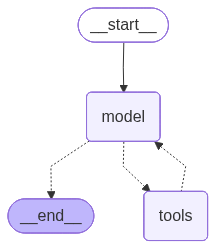

In [62]:
from langchain.agents import create_agent#, AgentExecutor

agent = create_agent(llm, tools) # primero inicializamos el agente ReAct
agent

Finalmente, probamos nuestro agente:

In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "qué equipo ganó el mundial de LoL 2024?"}]}
)

{'messages': [HumanMessage(content='qué equipo ganó el mundial de LoL 2024?', additional_kwargs={}, response_metadata={}, id='5a76f98f-7c1d-4c40-922d-a4fd0e4ad238'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "who won the LoL world championship 2024"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'grounding_metadata': {}, 'model_provider': 'google_genai'}, id='lc_run--36e74df4-1571-4e9b-836a-0117b485e1f4-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'who won the LoL world championship 2024'}, 'id': '6d1c3b31-d979-4fbb-b8bd-dd1547ac7257', 'type': 'tool_call'}], usage_metadata={'input_tokens': 62, 'output_tokens': 20, 'total_tokens': 82, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='[{"title": "2024 League of Legends World Championship - Wikipedia"

In [72]:
response["messages"][0]

HumanMessage(content='qué equipo ganó el mundial de LoL 2024?', additional_kwargs={}, response_metadata={}, id='5a76f98f-7c1d-4c40-922d-a4fd0e4ad238')

In [89]:
import json
print(json.dumps(dict(response["messages"][3]), indent=4, ensure_ascii=False).encode("utf8").decode())

{
    "content": "T1 ganó el Campeonato Mundial de League of Legends 2024.",
    "additional_kwargs": {},
    "response_metadata": {
        "prompt_feedback": {
            "block_reason": 0,
            "safety_ratings": []
        },
        "finish_reason": "STOP",
        "model_name": "gemini-2.0-flash",
        "safety_ratings": [],
        "grounding_metadata": {},
        "model_provider": "google_genai"
    },
    "type": "ai",
    "name": null,
    "id": "lc_run--8b368d6f-f72b-4be3-8e07-db90debfe27b-0",
    "tool_calls": [],
    "invalid_tool_calls": [],
    "usage_metadata": {
        "input_tokens": 505,
        "output_tokens": 16,
        "total_tokens": 521,
        "input_token_details": {
            "cache_read": 0
        }
    }
}


In [91]:
print(response["messages"][-1].content)

T1 ganó el Campeonato Mundial de League of Legends 2024.


### **Implementando nuestras propias tools**

Algo interesante que podemos hacer es **programar nuestras propias tools** para que el agente interactúe con ellas.

Revisemos un ejemplo en que programos tools con algunas **operaciones matemáticas**:

<center>
<img src='https://media1.tenor.com/images/dfe0c1c6eaf41b91996aacee0879ebc2/tenor.gif?itemid=3486402' width=400  />
</center>

In [92]:
from langchain.tools import tool

@tool
def multiply(x: int or float, y: int or float) -> float:
    """Multiply 'x' times 'y'."""
    return float(x * y)

@tool
def exponentiate(x: int or float, y: int or float) -> float:
    """Raise 'x' to the 'y'."""
    return float(x**y)

@tool
def add(x: int or float, y: int or float) -> float:
    """Add 'x' and 'y'."""
    return float(x + y)

Luego, simplemente agrupamos las tools en una lista:

In [93]:
tools = [add, multiply, exponentiate]

En paralelo, crearemos un **prompt** para nuestro agente:

In [98]:
# noten como ahora se incluye la variable agent_scratchpad
math_template = """
Eres un asistente experto en matemáticas.
Tu único rol es responder la pregunta del usuario usando las tools disponibles.

Pregunta: {input}
{agent_scratchpad}
"""

Con el prompt creado, pasamos a **crear nuestro agente**.

Noten que como nuestras tools reciben más de un parámetro de entrada (a y b), **remplazaremos ReAct por [Tool Calling](https://python.langchain.com/v0.1/docs/modules/agents/agent_types/tool_calling/)** (de igual manera, pueden encontrar todos los tipos de Agentes disponibles y sus limitantes en el siguiente [link](https://python.langchain.com/v0.1/docs/modules/agents/agent_types/)):

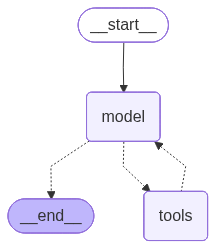

In [99]:

math_agent = create_agent(llm, tools, system_prompt=math_template)
math_agent

Finalmente, podemos probar el funcionamiento de nuestro agente:

In [101]:
response = math_agent.invoke({"messages": [{"role": "user", "content": "cuanto es 10 ** 3 + 5 * 1.4?"}]})
print(response["messages"][-1].content)

10 ** 3 = 1000
5 * 1.4 = 5 * (1 + 0.4) = 5 * 1 + 5 * 0.4 = 5 + 2 = 7
1000 + 7 = 1007

Respuesta: 1007


## **Soluciones Multi Agente 👨‍👩‍👦‍👦**

<center>
<img src='https://media.tenor.com/FApRE_u99tgAAAAC/teamwork-team-game.gif' width=400  />
</center>

En las secciones pasadas habilitamos agentes que puedan hacer RAG sobre fuentes externas:

- Una **chain** que responde preguntas de las últimas elecciones municipales en base a un informe en PDF
- Un **agente** que responde preguntas matemáticas a partir de tools creadas manualmente.

Con esto en consideración, nace la pregunta natural: **¿Qué pasa si combinamos ambas soluciones?**

El objetivo de esta sección es introducirlos al paradigma **multiagente**, es decir, **combinar 2 o más funcionalidades en un mismo chat**. En particular, buscaremos implementar una arquitectura simple de enrutamiento, la cual consta de 4 agentes:

- **Agente router**, el cual recibe y dirige la pregunta del usuario a alguno de los agentes.
- **Agente de elecciones**: responde preguntas sobre las elecciones municipales 2024
- **Agente experto en matemáticas**: responde preguntas matemáticas
- **Agente de redireccionamiento**: en caso de que la pregunta del usuario no pertenezca a alguno de los temas anteriores, invita al usuario a reorientar su pregunta (esto es útil para evitar preguntas maliciosas).

**Nota**: Para efectos de esta sección y por simplicidad, no se hace distinción entre Agente y Chain.

<center>
<img src='https://preview.redd.it/smart-orchestrator-router-for-multiple-specialized-llms-v0-gjgkmlbu3jlc1.png?width=627&format=png&auto=webp&s=13ef701d45f642ce36ae8e99cb172b903fe7d36b' width=600  />
</center>

De estos componentes, ya tenemos el agente de elecciones y el experto en matemáticas, y el de redireccionamiento es una simple chain. Sólo nos quedaría el **router**, el cual en base a la pregunta del usuario decidirá a cual de los 3 agentes ir. Para esto, el programa deberá tomar una decisión en base al output del LLM.

Sin embargo, los llm por defecto tienen salidas variantes. Incluso si se le da la instrucción específica de que solo puede responder una de 3 posibles opciones, el LLM podría introducir pequeñas variaciones o responder en una frase más larga. Incluso si el modelo es avanzado y se le da instrucciones muy estrictas, puede fallar. Para esto, haremos el uso de **output parsers**


**Importante: La implementación es sólo ilustrativa y <u>no cumple con el estándar actual recomendado por LangChain</u>. Si desean conocer mejor cómo implementar soluciones multiagente, les recomiendo estudiar [LangGraph](https://www.langchain.com/langgraph)**.

#### **Output parser**

Hasta ahora hemos visto ```StrOutputParser``` que simplemente transforma la salida del LLM en un objeto string. Sin embargo, una de las mejores características de langchain es que permite establecer un formato de salida muy específico donde _se asegura_ que se obtendrá en ese formato. Para esto, se apoyan de la lógica de **pydantic**, que es una librería ampliamente usada en python para hacer _type checking_ de variables.

> ***¿Pero como se setea esto en un modelo de lenguaje? ¿Qué clase de magia es esta?*** 
>
> Los output parsers logran esto envolviendo el prompt en instrucciones específicas con buenas prácticas de prompt al mismo tiempo que validan y corrigen la salida mediante un mecanismo de retry. En casos de que el modelo lo soporte, incluyen parámetros en la llamada al LLM lo cual activa meanismos internos adicionales para lograr esto. De esta forma, técnicamente no es 100% seguro que de el formato correcto, pero en la práctica se observará el 100% de las veces.

In [103]:
from pydantic import BaseModel, Field
from typing import Literal

class QuestionRoute(BaseModel):
    decision: Literal["elecciones", "math", "otro"] = Field(
        description="""
        Decisión sobre el agente más relevante para responder una pregunta.
        - 'elecciones': Cuando la pregunta se relacione específicamente con las elecciones municipales de chile 2024.
        - 'math': Cuando la pregunta sea relacionada a preguntas de matemáticas
        - 'otro': Todo aquella pregunta que no esté contenida en las categorías anteriores.
        """)

#### **Agente Router**

Primero comenzamos creando nuestro agente router:

In [105]:
router_prompt = PromptTemplate.from_template(
    """
    Eres un asistente experto en la clasificación de preguntas del usuario.
    Tu único rol es clasificar preguntas del usuario en las categorías 'elecciones', 'math', u 'otro'

    No respondas con más de una palabra y no incluyas.

    <pregunta>
    {question}
    </pregunta>

    Categoría:"""
)

structured_model = llm.with_structured_output(QuestionRoute)

router_chain = (
    router_prompt
    | structured_model
)

In [106]:
router_chain.invoke({"question": "cuanto es 2+2"})

QuestionRoute(decision='math')

In [107]:
router_chain.invoke({"question": "Qué partido sacó más votos en chile el 2024?"})

QuestionRoute(decision='elecciones')

In [108]:
router_chain.invoke({"question": "Qué alcalde ganó en nueva york el 2025?"})

QuestionRoute(decision='otro')

In [109]:
router_chain.invoke({"question": "Qué partido sacó más votos?"})

QuestionRoute(decision='elecciones')

#### **Agente Redirect**

Repetimos lo mismo para crear nuestro agente de redireccionamiento:

In [110]:
redirect_prompt = PromptTemplate.from_template(
    """
    Eres un asistente experto en el redireccionamiento de preguntas de usuarios.
    Vas a recibir una pregunta del usuario, tu único rol es indicar que no puedes responder su pregunta y redireccionar al usuario
    para que te pregunte sobre las elecciones municipales de Chile 2024 o cálculos matemáticos.

    Recuerda ser amable y cordial en tu respuesta.

    Pregunta: {question}
    Respuesta cordial:"""
)

redirect_chain = (
    redirect_prompt
    | llm
    | StrOutputParser()
)

redirect_chain.invoke({"question": "dame la receta para hacer una pizza"})

'Lamento mucho, pero no puedo ayudarte con recetas de cocina. Sin embargo, si tienes preguntas sobre las elecciones municipales de Chile 2024 o necesitas ayuda con cálculos matemáticos, ¡estaré encantado de asistirte!'

#### **Juntando todo**

Finalmente, podemos juntar todo lo que hemos desarrollado en una sola función:

In [132]:
def route_question(question):
  '''
  Recibe una pregunta de usuario.
  Rutea la pregunta al agente respectivo y responde de manera acorde.
  '''

  router_response = router_chain.invoke({"question": question}) # enrutamiento

  if "elecciones" in router_response.decision: # si la pregunta es sobre las elecciones, utilizar cadena
      return rag_chain.invoke(question)
  elif "math" in router_response.decision: # si la pregunta es de matemáticas, utilizar agente
      agent_input = {"messages": [{"role": "user", "content": question}]}
      return math_agent.invoke(agent_input)["messages"][-1].content
  else: # de lo contrario, redireccionar pregunta
      return redirect_chain.invoke({"question": question})

Para finalmente hacer pruebas de su funcionamiento:

In [133]:
print(route_question("cómo puedo hacerme millonario?"))

Lamento mucho, pero no puedo ofrecerte consejos sobre cómo hacerte millonario. Sin embargo, si tienes preguntas sobre las elecciones municipales de Chile 2024 o necesitas ayuda con algún cálculo matemático, ¡estaré encantado de ayudarte!


In [134]:
print(route_question("como fue la participación de las elecciones?"))

La participación en las elecciones fue alta en comparación con elecciones anteriores bajo el sistema de voto voluntario. Incluso, fue levemente superior a eventos recientes con voto obligatorio, consolidando la efectividad de estas medidas en aumentar la participación electoral.


In [135]:
print(route_question("cuanto es 5+3?"))

5+3 es 8.
